# Preamble

In [ ]:
from matplotlib import pyplot as plt # plotting
import math
import sklearn
import GPy
np.random.seed(101)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ExpSineSquared, ConstantKernel, DotProduct


import scipy
from tqdm import tqdm
#import pytorch as torch
import numpy as np
import gymnasium as gym
import gym_unbalanced_disk, time
env = gym_unbalanced_disk.UnbalancedDisk(dt=0.025, umax=3.) #alternative


# Environment setup

In [3]:
obs, info = env.reset()
try:
    for i in range(200):
        obs, reward, terminated, truncated, info = env.step(env.action_space.sample()) #random action
        #print(obs, reward)
        env.render()
        time.sleep(1/24)
        if terminated or truncated:
            obs = env.reset()
finally: #this will always run
    env.close()

/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# Class definitions

In [98]:
class environment:
    def __init__(self, x=None, y=None, alpha=10**-10, n_restarts_optimizer=10,quiet=False ): #, width=0.5, noise=0.1):
        self.alpha = alpha
        self.n_restarts_optimizer = n_restarts_optimizer
        self.quiet = quiet
        self.x = x
        self.y = y
        #self.width = width
        #self.noise = noise

class kern:
    def __init__(self, environment=None, f=None, cov=None, included=None, testpoints=None, kernel=None, skernel=None, width=None, noise=None, project=False):
        self.environment = environment
        self.f = f
        self.cov = cov

        self.included = included
        self.testpoints = testpoints
        if type(included)==None: included = np.ones([len(environment.x)],dtype='bool')
        if type(testpoints)==None: testpoints = included

        self.kernel = kernel
        self.skernel = skernel
        self.width = width
        self.noise = noise
        self.project = project

    
    def compute(self):
        x = self.environment.x
        y = self.environment.y
        self.xm = x[self.included]
        self.Kmm = slice(self.xm,self.xm,self.kernel,self.width)
        self.Km2 = slice(self.xm,x[self.testpoints],self.kernel,self.width)
        self.K22 = slice(x[self.testpoints],x[self.testpoints],self.kernel,self.width)

        if self.project==True:
            self.Km1 = slice(self.xm,x,self.kernel,self.width)
            self.Kmm_inv = np.linalg.inv(self.noise**2 *self.Kmm + self.Km1@self.Km1.T)
            y = self.Km1@y
        else: 
            self.Km1 = None
            self.Kmm_inv = np.linalg.inv(np.eye(len(self.xm))*self.noise**2 + self.Kmm)

        self.A = self.Km2.T@self.Kmm_inv
        self.f = self.A@y
        self.cov = self.K22 - self.A@self.Km2
        self.var = np.diag(self.cov)
        
        

In [99]:
env_pp = environment(x=x1,y=y1)
kern_pp = kern(environment=env_pp, included=include_sd, kernel=rbf, width=0.5, noise=0.1, project=True)
print(len(kern_pp.environment.x))

kern_pp.compute()
demonstrate(full_range,y1, kern_pp.f, kern_pp.var , kern_pp.testpoints,"PP")

35000
incompatible input dimensions


AttributeError: 'NoneType' object has no attribute 'T'

# Function definitions

In [46]:
def rbf (x1, x2, width):
    return np.exp(- (np.sum((x1 - x2)**2))/width)

def rbf_clip (x1, x2, width):
    euc = np.mean((x1 - x2)**2)
    if euc>width:
        return 0
    else:
        return np.exp(- euc/width)

def uniform (x1, x2, width):
    return (np.mean((x1 - x2)**2)>=width)*0.5

def slice(x1,x2,kernel,width,axis=1):
    n1 = x1.shape[0]
    n2 = x2.shape[0]
    dim = x1.shape[1]

    if dim != x2.shape[1]:
        print("incompatible input dimensions")
        return
    if (n1!=n2)&(axis==0):
        print("incompatible input lengths")
        return

    if axis==0:
        out = np.zeros([n1])
        for i in range(n1):
            out[i] = kernel(x1[i,:],x2[i,:],width)
        return out
    else:
        out = np.zeros([n1, n2])
        for i in range(n1):
            for j in range(n2):
                out[i,j] = kernel(x1[i,:],x2[j,:],width)
        return out

def Kcomp(x1,x2,width,kernel,project=False,included=0):
    if project==True:
        xm = x1[included]
        Kmm = slice(xm,xm,kernel,width)
        Km1 = slice(xm,x1,kernel,width)
        #K1m = Km1.T
        Km2 = slice(xm,x2,kernel,width)
        #K2m = Km2.T
        K22 = slice(x2,x2,kernel,width)
        return Kmm,Km1,Km2,K22
    else:
        K11 = slice(x1,x1,kernel,width)
        K12 = slice(x1,x2,kernel,width)
        #K21 = K12.T
        K22 = slice(x2,x2,kernel,width)
        return K11,K12,K22

def post(x1,x2,y,width,kernel,noise,environment,project=False,included=None):
    N = len(x1)
    if project==True:
        Kmm,Km1,K1m,Km2,K2m,K22 = Kcomp(x1,x2,width,kernel,project,included)
        f = Km2.T@np.linalg.inv(noise**2 *Kmm + Km1@Km1.T)@Km1@y
        
        Kmm_inv = np.linalg.inv(Kmm)
        err_inv = np.linalg.inv(Kmm + Km1@K1m/(noise**2))
        cov = K22 - Km2.T@(Kmm_inv - err_inv)@Km2
        return f,cov

    else:
        #K11,K12,K22 = Kcomp(x1,x2,width,kernel,project)
        #K11_inv = np.linalg.inv(K11 + np.eye(N)*noise**2)
        #A = K12.T@K11_inv
        #f = A@y
        #cov = K22 - A@K12

        reg = GaussianProcessRegressor(kernel,alpha=environment.alpha,n_restarts_optimizer=environment.n_restarts_optimizer) 
        reg.fit(x1,y)
        f, cov = reg.predict(x2,return_cov=True)

        #f = K12.T@K11_inv@y
        #cov = K22 - K12.T@K11_inv@K12
        return f,cov,reg


def MSLL(y1,y2,noise,var,project=False,included=0):
    if y1.ndim > 1: y1 = y1[:,0]
    if y2.ndim > 1: y2 = y2[:,0]
    if var.ndim > 1: var = var[:,0]

    star = noise**2 + var
    log_loss = ( 0.5 * np.log(2*np.pi*star)) + ( (y1 - y2)**2 / (2*star))

    if project==False:
        simple_mean, simple_var =  np.mean(y1), np.std(y1)**2
    else:
        simple_mean, simple_var =  np.mean(y1[included]), np.std(y1[included])**2

    simple_star = noise**2 + simple_var
    simple_loss = ( 0.5 * np.log(2*np.pi*simple_var)) + ( (y1 - simple_mean)**2 / (2*simple_var))
    return np.mean(log_loss - simple_loss)

def sd_algo(x1,x2,y,M_sd,width,kernel,noise,environment,testiness=0.5):
    N = y.shape[0]
    included = np.array(np.zeros(N),dtype="bool")
    i = np.random.randint(low=0,high=N-1)
    included[i] = True

    testpoints = np.random.uniform(low=0,high=1,size=[N]) > (1-testiness)

    for m in tqdm(range(M_sd)):
        f,cov,reg = post(x1[included,:],x2[testpoints,:],y1[included,:],width,kernel,noise,environment)
        var = np.diag(cov)
        i_new = np.argmax(var)
        included[i_new] = True
    
    if environment.quiet==False: return f,var,included,cov,testpoints,reg
    if environment.quiet==True: return f,included,cov,reg

def ARX_load_input(u,y,batches=1,order=1):
    n = u.shape[0]
    N = int(n/batches)
    ux = np.concat(([0],u),axis=0)
    yx = np.concat(([0],y),axis=0)

    ux_temp = np.zeros([n,order])
    yx_temp = np.zeros([n,order])

    for i in range(batches):
        ux_temp[i*N:((i+1)*N),:] = scipy.linalg.toeplitz(u[i*N:((i+1)*N)])[:,0:order]
        yx_temp[i*N:((i+1)*N),:] = scipy.linalg.toeplitz(y[i*N:((i+1)*N)])[:,0:order]

    ux = np.tril(ux_temp,k=-1)[0:n,0:order]
    yx = np.tril(yx_temp,k=-1)[0:n,0:order]
    
    return np.concat((ux,yx),axis=1)

def demonstrate(full_range,y1,f,var,testpoints,name):
    plt.figure(figsize=(16,4.8))
    plt.title(name)
    plt.plot(full_range,y1,label="Data",marker=".")
    plt.plot(full_range[testpoints],f,label="Prediction")
    plt.fill_between(full_range[testpoints],f+var,f-var,alpha=0.3,label='est std out')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.show()
    return

# Data

In [189]:
N=35000
V=15000


readout = np.loadtxt('/home/sodium-nitrate/aur/gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv',delimiter=',',dtype=float)[0:(N+1),:]

readout_u = readout[:,0]
readout_y = readout[:,1]



#norm_u = (np.max(readout_u ) - np.min(readout_u ))
#norm_y = (np.max(readout_y ) - np.min(readout_y ))

#norm_u = np.std(readout_u)
#norm_y = np.std(readout_y)
#
#
#mean_u = np.mean(readout_u)
#mean_y = np.mean(readout_y)
#
#
#readout_u = (readout_u-mean_u)/norm_u
#readout_y = (readout_y-mean_y)/norm_y



scaler = StandardScaler()
readout_y = scaler.fit_transform(readout_y[:,None])[:,0]
readout_u = scaler.fit_transform(readout_u[:,None])[:,0]

x1 = ARX_load_input(readout_u,readout_y,batches=100,order=3)
x2 = x1
y1 = readout_y[0:N,None]
full_range = np.array(range(y1.shape[0]))

k_folds = 10

kernel = rbf


In [169]:
range_u = (np.max(readout_u ) - np.min(readout_u ))
range_y = (np.max(readout_y ) - np.min(readout_y ))
print(range_u,range_y)

7.621672224339338 8.513688972077539


# Processes

## Classical GP

In [ ]:
# CLASSICAL GP

width = 0.1
noise = 0.01

classic_start = time.time()
f,cov,reg = post(x1,x2,y1,width,kernel,noise)
var = np.diag(cov)[:,None]
classic_end = time.time()
classic_run = classic_end - classic_start
classic_msll = MSLL(y1,f,noise,var)

f = f[:,0]
var = var[:,0]

demonstrate(full_range,y1,f,var,testpoints=full_range,name='Classic GP')

KeyboardInterrupt: 

## Subset of Data GP

In [69]:
# SD GP

env_sd = environment()

width_sd = 0.5
noise_sd = 0.1
M_sd = 500

sd_start = time.time()

ker_sd =  WhiteKernel(noise_level=noise_sd, noise_level_bounds=(1e-9, 1e1))  + RBF(length_scale=width_sd)# + ConstantKernel() #DotProduct()   #a=)

f_sd,var_sd,include_sd,cov_sd,testpoints_sd,reg_sd = sd_algo(x1,x2,y1,M_sd,width_sd,ker_sd,noise_sd,env_sd,testiness=0.01)

sd_end = time.time()
sd_run = sd_end - sd_start



  0%|          | 0/500 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
 10%|█         | 50/500 [00:02<00:26, 16.77it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__noise_level is close to the specified lower bound 1e-09. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
 12%|█▏        | 60/500 [00:03<00:25, 17.20it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__noise_leve

0.571076163272318
0.47933732021423614


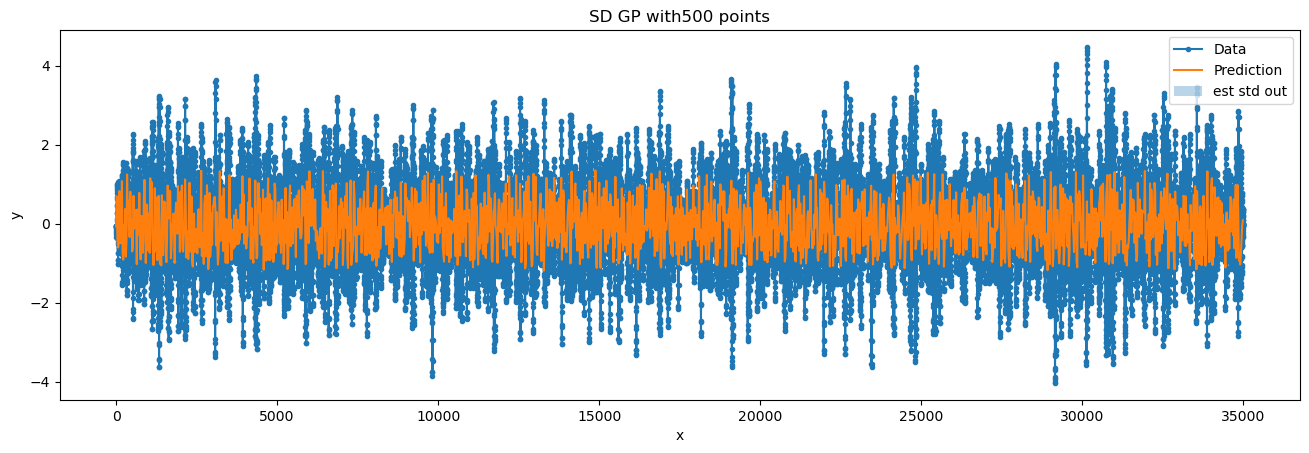

In [72]:
testpoints_sd = (np.mod(range(N),20)==0)
f_sd,cov_sd = reg_sd.predict(x2[testpoints_sd],return_cov=True)
var_sd = np.diag(cov_sd)

sd_msll = MSLL(y1[testpoints_sd,:],f_sd,noise_sd,var_sd)
sd_rmse = np.mean((y1[testpoints_sd]-f_sd)**2)**0.5

print(sd_rmse*norm_y)
print(norm_y)

name = "SD GP with" + str(M_sd) + " points"
demonstrate(full_range,y1,f_sd,var_sd,testpoints_sd,name)

## Projective Process

In [73]:
# PP GP


env_pp = environment()
width_pp = 0.5
noise_pp = 0.1
ker_pp = rbf

pp_start = time.time()
f_pp,cov_pp = post(x1,x2,y1,width_pp,ker_pp,noise_pp,environment=env_pp,project=True,included=include_sd)
var_pp = np.diag(cov_pp)[:,None]
pp_end = time.time()
pp_run = pp_end - pp_start + sd_run
pp_msll = MSLL(y1,f_pp,noise_pp,var_pp,project=True,included=include_sd)

f_pp = f_pp[:,0]
var_pp = var_pp[:,0]



KeyboardInterrupt: 

In [ ]:
name = 'Projective GP'
testpoints_pp = np.ones([N],dtype="bool")
demonstrate(full_range,y1,f_pp,var_pp,testpoints_pp,name)

# Bayseian committee machine

In [257]:
# Setup

width_bcm = 0.5
noise_bcm = 0.1

p_bcm = 70 #no of partitions
v_bcm = 35 #no of partitions to use for each validation


M_bcm = 500 #partition block size

#t_bcm = 35000 #test block size
##t_bcm = v_bcm*M_bcm
##testpoints_bcm = (np.mod(range(N),1)==0)

training = np.array(range(N)) < N-V
validation = training!=True

x_test = x2[validation]


#[p*M_bcm:((p+1)*M_bcm),:]

#Try to combine SD with BCM?

#hyperinclude_bcm = np.ones([N,p_bcm],dtype='bool')

# + *ExpSineSquared(length_scale=0.5,periodicity=0.5)

ker_bcm =  WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-3, 1e1))  + RBF(length_scale=0.5) + ConstantKernel() #DotProduct()   #a=)


In [285]:
np.power([1, 2, 3],-1.5)

array([1.        , 0.35355339, 0.19245009])

In [369]:
def BCM_predict(x22,reg_bcm,kernel,width_bcm,partitions_used,N,beta=1):
    t_bcm = x22.shape[0]
    prediction_blocks = len(partitions_used)
    #Initialisation
    f_bcm = np.array(np.zeros([t_bcm, prediction_blocks]))
    f_bcm_run = np.array(np.zeros(t_bcm))
    var_bcm = f_bcm
    include_bcm = np.array(np.zeros([N, prediction_blocks]),dtype="bool")
    inv_cov_bcm = np.array(np.zeros([t_bcm, prediction_blocks]))
    inv_cov_bcm_run = np.array(np.zeros([t_bcm]))

    #accumulating and combining predictions
    for i in range(prediction_blocks):
        f_bcm[:,i], inv_cov_bcm[:,i] = reg_bcm[int(partitions_used[i])].predict(x22,return_std=True)

        inv_cov_bcm[:,i] = inv_cov_bcm[:,i]**-beta
        inv_cov_bcm_run = inv_cov_bcm_run + inv_cov_bcm[:,i]
        f_bcm_run = f_bcm_run + inv_cov_bcm[:,i]*f_bcm[:,i]
    
    inv_cov_bcm_run = inv_cov_bcm_run**(1/beta)
    #print(inv_cov_bcm_run)
    K22 = slice(x22,x22,kernel,width_bcm,axis=0)
    cov_bcm = ( -(prediction_blocks-1)*(K22**-1) + inv_cov_bcm_run)**-1
    var_bcm = cov_bcm
    f_bcm = (cov_bcm*f_bcm_run)
    f_bcm = f_bcm/np.std(f_bcm)

    return f_bcm,var_bcm

def BCM_train(x1,y1,ker_bcm,p_bcm,N):
    #yeah it's training idk
    reg_bcm = np.zeros([p_bcm],dtype='object')
    for p in tqdm(range(p_bcm)):
        x11 = x1[np.mod(np.array(range(N))+p,p_bcm)==0]
        y11 = y1[np.mod(np.array(range(N))+p,p_bcm)==0]
        
        reg_bcm[p] = GaussianProcessRegressor(ker_bcm,alpha=10**-6, n_restarts_optimizer=10) #a=)
        reg_bcm[p].fit(x11,y11) #a)
    return reg_bcm

def BCM_validate(x22,y1,reg_bcm,kernel,width_bcm,testpoints_bcm,k_folds,p_bcm,v_bcm,N,beta=1):
    
    nbcm_rmse = np.array(np.zeros(k_folds))
    for k in range(k_folds):
        p_val = np.random.choice(np.array(range(p_bcm)),size=v_bcm,replace=False)  #generate random indices of PARTITIONS to use for validation
        p_train = np.array([item for item in range(p_bcm) if item not in p_val])

        #p_train = np.array(range(p_bcm))
        #p_val = np.array(range(v_bcm))+p_bcm

        #print("validation parts: ", p_val, "training parts: ", p_train)

        valpoints = np.array(np.zeros(N,dtype='bool'))
        for p in p_val:
            valpoints = valpoints + (np.mod(np.array(range(N))+int(p),p_bcm)==0)  #This computes the indices of the DATAPOINTS to use for validation from the partitions
        f_bcm,var_bcm = BCM_predict(x22[valpoints],reg_bcm,kernel,width_bcm,p_train,N,beta) #the prediction is made only on validation for most pessimistic estimate possible
        nbcm_rmse[k] = sklearn.metrics.root_mean_squared_error(y1[valpoints], f_bcm)

    return nbcm_rmse

In [263]:
## Training
bcm_start = time.time()
reg_bcm = BCM_train(x1[training],y1[training],ker_bcm,p_bcm,N-V)
bcm_end = time.time()
bcm_run = bcm_end - bcm_start

  0%|          | 0/70 [00:00<?, ?it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__noise_level is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
  1%|▏         | 1/70 [00:00<00:53,  1.29it/s]/home/sodium-nitrate/miniconda3/envs/ml4sc/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__noise_level is close to the specified lower bound 0

In [ ]:
f_bcm,var_bcm = BCM_predict(x1,reg_bcm,kernel,width_bcm,range(p_bcm),N,beta=0.85)
bcm_rmse = BCM_validate(x1,y1,reg_bcm,kernel,width_bcm,testpoints_bcm,k_folds,p_bcm,v_bcm,N,beta=0.85)*norm_y


WhiteKernel(noise_level=0.001) + RBF(length_scale=6.66) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.77) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.79) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.88) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.94) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.94) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=7.07) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=7.07) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.95) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.79) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.67) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.7) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.72) + 0.00316**2
WhiteKernel(noise_level=0.001) + RBF(length_scale=6.75) + 0.00316**2
WhiteKernel(noise_level=0.001) + RB

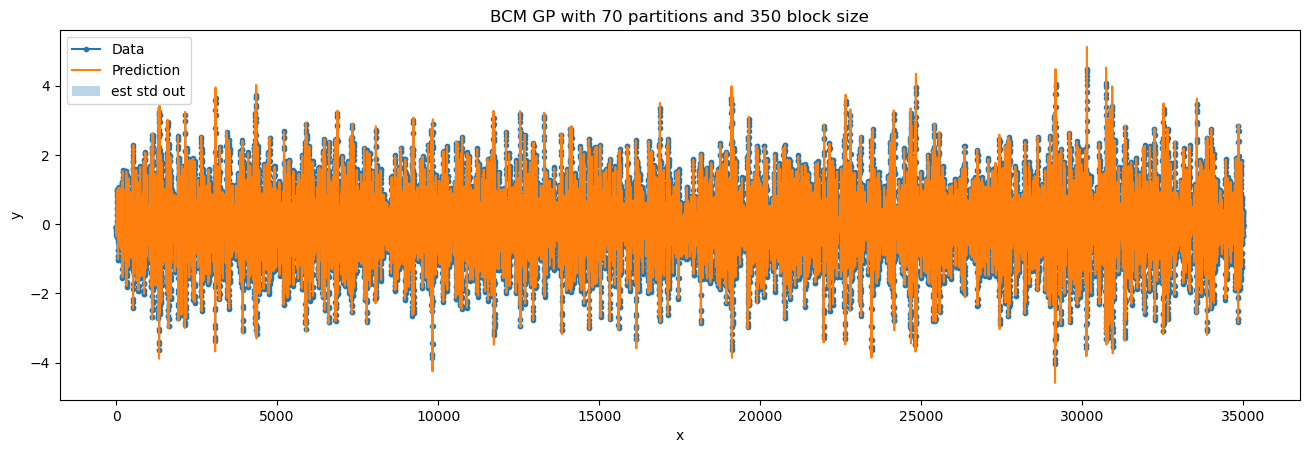

mean RMSE:  0.013497119462461488 
 std RMSE:  0.0003257173481619407


In [371]:

for p in range(p_bcm): print(reg_bcm[p].kernel_)

name = 'BCM GP with ' + str(p_bcm) + " partitions and " + str(s_bcm) + " block size"
demonstrate(full_range,y1,f_bcm,var_bcm,testpoints_bcm,name)
print("mean RMSE: ", np.mean(bcm_rmse), "\n","std RMSE: ", np.std(bcm_rmse), )

[1.15386886e-15 1.41421356e+00 1.73205081e+00]


In [261]:
print("Log-marginal-likelihood:", reg_bcm[0].log_marginal_likelihood_value_)
print("Log-marginal-likelihood:", reg_bcm[0].kernel_)

Log-marginal-likelihood: 618.1390347197669
Log-marginal-likelihood: WhiteKernel(noise_level=0.001) + RBF(length_scale=6.66) + 0.00316**2


# Predictions task

In [50]:
#print("Classic algorithm runtime = ", classic_run)
#print("Classic algorithm utility = ", -classic_msll, "\n")

print("SD algorithm runtime = ", sd_run)
print("SD algorithm utility = ", -sd_msll)
print("SD algorithm RMSE = ", sd_rmse, "\n")

#
#print("PP algorithm runtime = ", pp_run)
#print("PP algorithm utility = ", -pp_msll, "\n")

print("BCM algorithm runtime = ", bcm_run)
print("BCM algorithm utility = ", -bcm_msll)
print("BCM algorithm RMSE = ", bcm_rmse)

print(norm_y)

SD algorithm runtime =  31.681506395339966
SD algorithm utility =  0.6592237204866935
SD algorithm RMSE =  1.1337316753020834 



NameError: name 'bcm_run' is not defined